In [ ]:
# 5. [종합 실습 1] 산탄데르 고객 만족 예측
# 이번 실습에서는 캐글의 'Santander Customer Satisfaction' 데이터를 사용하여 고객 만족 여부(불만족)를 예측하는 모델을 만들어보겠다.
# 이 데이터는 370 개의 피처로 구성되어 있으며, 클래스가 매우 불균형한(0:만족 96%, 약 4%만 1:불만족) 특징을 가집니다. 
# 평가 지표는 ROC-AUC 를 사용. (일반화성능은 아니다. - 양성[positive]를 지표로 삼는거다)
# 불균형데이터라서 분류 평가지표인 'accuracy'로는 안됨. 
# => DummyClassifier[-학습안하고 predict()예측만하는데도)에 넣어도 기본 0.96 나와버림
# => XGBClassifier()에서 .fit(학습시키고) -> predict() 하면 0.9997 -> 불만족을 이상치로 처리해버림

In [2]:
# 필요한 package import
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

In [3]:
# data loading
cust_df = pd.read_csv('../data/train.csv')
print('dataset shape:', cust_df.shape) # (76020, 371)

dataset shape: (76020, 371)


In [3]:
cust_df.head(3) # TARGET(label) 이 들어 있음 - 컬럼의 용도를 모름

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.17,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.77,0


In [7]:
cust_df.info() 
# memory보소! 215.2B 실제 현업에서는 GB 단위로 나올꺼다
# object type이 없다. int64(260개 컬럼) data안에 category(범주형) 있을 수 있다
# Tree 계열은 전처리에 덜 민감하지 않다는게 장점임! 반대로 회귀 계열은 민감하다(scaling해야), 이상치에는 민감하다
# XGB 사용할꺼다(야는 tree 계열)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [4]:
# 레이블의 분포 확인
cust_cnt = cust_df['TARGET'].value_counts()
print(cust_cnt) # 1이 불만족 3008명, 만족이 73012

# 불만족고객의 비율
cust_rate = cust_cnt[1] / cust_cnt.sum()
print(f'불만족 고객 비율: {cust_rate:.2f}')

TARGET
0    73012
1     3008
Name: count, dtype: int64
불만족 고객 비율: 0.04


In [8]:
# 데이터 통계량 확인
cust_df.describe() # 수치 데이터에 대한 통계량
# var3(min:-999999 무의미한 값인 듯) 도 전처리된 데이터로 보임
# 컬럼간 scale이 다름 => Tree 계열인 XGB로 할꺼라서, saldo_medio_var44_hace3(과거잔고평균액?), max가 큰값들에 대한 target를 확인해봐라
# 0 이 많다? 희소행렬아냐? XGB는 Tree계열이라 상관없어! 땅따먹기 식이니까. 
# 하지만 DeepLearning에서는 전처리에 민감해서 전처리 해야 해(scale), 0 도 많아~

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


In [ ]:
# data preparing(전처리) : var3 feature만
print(cust_df.var3.value_counts()) # cust_df['var3'].value_counts()과 동일 : df에서는 컬럼명을 . 으로 접근 가능


In [4]:
# 1. var3 feature : 최빈값 = 2, -99999 를 116개를 최빈값으로 
# cust_df['var3'] = cust_df['var3'].replace(-999999, 2, inplace=False) # inplace=False 로 주면 변경이이 반환되니까 대입받아야 하고
cust_df['var3'].replace(-999999, 2, inplace=True) # inplace=True 이 경우 대입하면 'None' 으로 바뀌는 대참사가 일어남!!!!

In [5]:
# 2. ID feature drop - DF에서 삭제해야 함
cust_df.drop('ID', axis=1, inplace=True)

In [11]:
print(cust_df.var3.value_counts()) # -9999 업어짐

var3
2      74281
8        138
9        110
3        108
1        105
       ...  
63         1
194        1
40         1
57         1
87         1
Name: count, Length: 207, dtype: int64


### 🌳 Tree 계열 모델 vs SVC
- **XGB (XGBoost)**: 전처리에 덜 민감함 → 실무에서 안정적으로 사용 가능
- **SVC (Support Vector Classifier)**: 성능은 우수하지만 **전처리에 매우 민감**함
> 세미 프로젝트에서는 다양한 모델을 실험해보는 것이 중요!
---
### ⚠️ 이 데이터의 잠재적 문제점

> XGB에서는 큰 문제가 되지 않지만, **딥러닝 모델에서는 주의가 필요**.
1. **Feature Sparsity (희소성)**  
   - 0이 많은 데이터 → 메모리 낭비 및 학습 효율 저하  
   - 일부 모델에서는 성능 저하 가능성 있음
2. **High Correlation (높은 상관관계)**  
   - 다중 공선성 발생 → 모델의 신뢰성 및 해석력 저하  
   - 예: 유사한 의미의 feature들이 동시에 존재
3. **Skewed Distribution (치우친 분포)**  
   - 일부 feature가 한쪽으로 몰려 있음  
   - 예: `var15(age)`, `var38(?)`, `saldo_` 관련 feature들  
   - 정규화 또는 로그 변환 등의 처리가 필요할 수 있음
4. **Feature Engineering 필요성**  
   - `Feature Extraction`: 기존 feature를 가공해 새로운 feature 생성  
   - `Feature Selection`: 의미 있는 feature만 선택하여 사용
---
### 💡 Feature 해석 팁

- **0의 의미**:  
  - 해당 feature가 상품이라면,  
    - `0`: 해당 서비스를 사용하지 않음  
    - `1`: 사용함 → 고객의 **활동성 지표**로 활용 가능    

- **saldo의 의미**:  
  - 여러 `saldo_` feature를 합치면 **총 잔액**으로 해석 가능

- ** num : 거래 횟수 **
- ** imp : 거래 금액 **

In [8]:
# 데이터와 레이블 분리
X_features = cust_df.iloc[:, :-1]
y_labels = cust_df['TARGET']
print(f'데이터 구조: {X_features.shape}')

데이터 구조: (76020, 369)


In [9]:
# 학습/테스트 데이터 분리
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X_features, 
  y_labels,
  test_size    = 0.2, 
  random_state = 0
)

In [10]:
# 균형성 확인
train_cnt = y_train.count()
test_cnt  = y_test.count()
print(f'학습(Learning) Label cnt: {train_cnt}, Test Label cnt: {test_cnt}')

학습(Learning) Label cnt: 60816, Test Label cnt: 15204


In [ ]:
print(y_train.value_counts())

TARGET
0    58442
1     2374
Name: count, dtype: int64


In [ ]:
print(y_train.value_counts()/train_cnt) # 학습레이블의 비율 구하기 (brodcasting일어나서 Seriex)

TARGET
0    0.960964
1    0.039036
Name: count, dtype: float64


In [ ]:
print(y_test.value_counts()/test_cnt) # 테스트레이블의 비율, 위와 다름!!! 

TARGET
0    0.9583
1    0.0417
Name: count, dtype: float64


In [13]:
# train와 test label의 분포가 다름!!! 이걸 좀 조정하자
X_train, X_test, y_train, y_test = train_test_split(
  X_features, 
  y_labels,
  test_size    = 0.2, 
  random_state = 0,
  stratify     = cust_df['TARGET'] # 위 문제를 해결하기 위해
)

In [14]:
# 학습/검증 데이터 세트로 분리. 
X_tr, X_val, y_tr, y_val = train_test_split(
  X_train, 
  y_train,
  test_size    = 0.3, 
  random_state = 0
)

In [15]:
# Model 학습, 평가
from xgboost          import XGBClassifier
from sklearn.metrics  import roc_auc_score

# Base Model (no tuing)
xgb_clf = XGBClassifier(
    n_estimators    = 500,
    learning_rate   = 0.05,
    early_stopping  = 100,
    eval_metric    = 'auc',
    random_state    = 156    
)

In [16]:
xgb_clf.fit(
  X_tr,
  y_tr,
  eval_set=[(X_val, y_val)]
)

[0]	validation_0-auc:0.81114
[1]	validation_0-auc:0.81165
[2]	validation_0-auc:0.81430
[3]	validation_0-auc:0.81415
[4]	validation_0-auc:0.81527
[5]	validation_0-auc:0.81578
[6]	validation_0-auc:0.81610
[7]	validation_0-auc:0.81884
[8]	validation_0-auc:0.81914
[9]	validation_0-auc:0.81884
[10]	validation_0-auc:0.81930
[11]	validation_0-auc:0.82126
[12]	validation_0-auc:0.82348
[13]	validation_0-auc:0.82486
[14]	validation_0-auc:0.82564
[15]	validation_0-auc:0.82689
[16]	validation_0-auc:0.82787
[17]	validation_0-auc:0.82806
[18]	validation_0-auc:0.82814
[19]	validation_0-auc:0.82855
[20]	validation_0-auc:0.82873
[21]	validation_0-auc:0.82890
[22]	validation_0-auc:0.82876
[23]	validation_0-auc:0.82926
[24]	validation_0-auc:0.82937
[25]	validation_0-auc:0.82949
[26]	validation_0-auc:0.82943
[27]	validation_0-auc:0.82964
[28]	validation_0-auc:0.82994
[29]	validation_0-auc:0.83020
[30]	validation_0-auc:0.83042
[31]	validation_0-auc:0.83025
[32]	validation_0-auc:0.83052
[33]	validation_0-au

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [17]:
# ROC의 AUC(Area Under Cuve) 점수
xgb_roc_auc_score = roc_auc_score(
  y_test,
  xgb_clf.predict_proba(X_test)[:, 1] # Positive's 예측값
)
print(f'ROC AUC : {xgb_roc_auc_score:.4f}') # ROC AUC : 0.8385

ROC AUC : 0.8128


In [18]:
# hyperopt , kfold 사용해서 튜닝
from hyperopt                import hp
from sklearn.model_selection import KFold
from sklearn.metrics         import roc_auc_score


# 1. search_space 설정
xgb_search_space = {
  'max_depth'        : hp.quniform('max_depth', 5, 15, 1),
  'min_child_weight' : hp.quniform('min_child_weight', 1, 6, 1),
  'colsample_bytree' : hp.uniform('colsample_bytree', 0.5, 0.95), # feature rate : 50% ~ 95%
  'learning_rate'    : hp.uniform('learning_rate', 0.01, 0.2)
}

# 2. objective fuction 지정, decoration 쓸 수 있도록 해 봐라


# def objective_func(search_spae, model):
#     model_clf = model()
def objective_func(search_space):
    xgb_clf = XGBClassifier(
      n_estimators  =  100, # 작은 수를 주는 것이 좋다. (100도 충분히 작은 수다)
      max_depth        = int(search_space['max_depth']),
      min_child_weight = search_space['min_child_weight'],
      colsample_bytree = search_space['colsample_bytree'], 
      learning_rate    = search_space['learning_rate'],
      early_stopping   = 30,
      # early_stopping_rounds=30
      eval_metric      = 'auc', # 높은게 좋은 값이지?  
    )
  
    # 3개 Kfold 사용
    roc_auc_list = []
    kf = KFold(n_splits=3) # obj만 생성
    
    for tr_idx, val_idx in kf.split(X_train): # X_train : 6만건를 K(3)개로 나누기
        X_tr,  y_tr  = X_train.iloc[tr_idx],  y_train.iloc[tr_idx]  # 학습용
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx] # 평가용(auc값 구할때)
        
        xgb_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
            
        score = roc_auc_score(y_val, xgb_clf.predict_proba(X_val)[:, 1]) # positive 예측을 뽑기 위해
        roc_auc_list.append(score)
          
    return -1 * np.mean(roc_auc_list) # auc가 큰 값이 좋은 값이니까 -1 곱해서 작게 만들기
  

# 3. fmin() 돌리기
from hyperopt import fmin, tpe, Trials

trials = Trials()

best = fmin(
  fn        = objective_func,
  space     = xgb_search_space,
  algo      = tpe.suggest,
  max_evals = 50,
  trials    = trials,
  rstate    = np.random.default_rng(seed=30)
)

# Best : {'colsample_bytree': np.float64(0.7918890793294482), 'learning_rate': np.float64(0.04101063504864888), 'max_depth': np.float64(5.0), 'min_child_weight': np.float64(5.0)}

[0]	validation_0-auc:0.76225                          
[1]	validation_0-auc:0.76713                          
[2]	validation_0-auc:0.77095                          
[3]	validation_0-auc:0.81039                          
[4]	validation_0-auc:0.80941                          
[5]	validation_0-auc:0.82267                          
[6]	validation_0-auc:0.82746                          
[7]	validation_0-auc:0.83076                          
[8]	validation_0-auc:0.82941                          
[9]	validation_0-auc:0.83214                          
[10]	validation_0-auc:0.83139                         
[11]	validation_0-auc:0.83419                         
[12]	validation_0-auc:0.83258                         
[13]	validation_0-auc:0.83170                         
[14]	validation_0-auc:0.83461                         
[15]	validation_0-auc:0.83507                         
[16]	validation_0-auc:0.83678                         
[17]	validation_0-auc:0.83675                         
[18]	valid

In [19]:
print(f'Best : {best}')
print(trials.results)

Best : {'colsample_bytree': np.float64(0.6429668862932872), 'learning_rate': np.float64(0.03881854250752103), 'max_depth': np.float64(5.0), 'min_child_weight': np.float64(5.0)}
[{'loss': -0.8411135983853065, 'status': 'ok'}, {'loss': -0.8402767719024321, 'status': 'ok'}, {'loss': -0.8276924806669981, 'status': 'ok'}, {'loss': -0.8384593706284429, 'status': 'ok'}, {'loss': -0.8187257145219702, 'status': 'ok'}, {'loss': -0.8414109127767825, 'status': 'ok'}, {'loss': -0.8390096162004904, 'status': 'ok'}, {'loss': -0.8352342870720694, 'status': 'ok'}, {'loss': -0.8381337252200703, 'status': 'ok'}, {'loss': -0.8217033375098026, 'status': 'ok'}, {'loss': -0.8339129932412915, 'status': 'ok'}, {'loss': -0.8188237418587451, 'status': 'ok'}, {'loss': -0.8417658288937121, 'status': 'ok'}, {'loss': -0.8371065531605698, 'status': 'ok'}, {'loss': -0.8438393752209125, 'status': 'ok'}, {'loss': -0.8239108390082609, 'status': 'ok'}, {'loss': -0.8419209772007202, 'status': 'ok'}, {'loss': -0.82713574529

In [20]:
# BEST tuning 값으로 다시 돌려보기 
xgb_clf = XGBClassifier(
  n_estimators     = 1000,
  learning_rate    = round(best['learning_rate'], 5),
  max_dept         = int(best['max_depth']),
  min_child_weight = best['min_child_weight'],
  colsample_bytree = round(best['colsample_bytree'], 5),
  early_stopping_rounds=100,
  eval_metric='auc'
)
xgb_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])

[0]	validation_0-auc:0.73382
[1]	validation_0-auc:0.74683
[2]	validation_0-auc:0.74732
[3]	validation_0-auc:0.79314
[4]	validation_0-auc:0.78952
[5]	validation_0-auc:0.80102
[6]	validation_0-auc:0.81134
[7]	validation_0-auc:0.81657
[8]	validation_0-auc:0.81569
[9]	validation_0-auc:0.81898
[10]	validation_0-auc:0.81777
[11]	validation_0-auc:0.82045
[12]	validation_0-auc:0.81974
[13]	validation_0-auc:0.81895
[14]	validation_0-auc:0.82110
[15]	validation_0-auc:0.82000
[16]	validation_0-auc:0.82184
[17]	validation_0-auc:0.82095
[18]	validation_0-auc:0.82238
[19]	validation_0-auc:0.82370
[20]	validation_0-auc:0.82520
[21]	validation_0-auc:0.82434
[22]	validation_0-auc:0.82538
[23]	validation_0-auc:0.82496
[24]	validation_0-auc:0.82583
[25]	validation_0-auc:0.82677
[26]	validation_0-auc:0.82747
[27]	validation_0-auc:0.82791
[28]	validation_0-auc:0.82786
[29]	validation_0-auc:0.82788
[30]	validation_0-auc:0.82762
[31]	validation_0-auc:0.82832
[32]	validation_0-auc:0.82881
[33]	validation_0-au

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,np.float64(0.64297)
,device,None
,early_stopping_rounds,100
,enable_categorical,False
,eval_metric,'auc'


In [ ]:
import xgboost
print(xgboost.__version__) # we 3.1.1 vs Teacher 2.0.2

3.1.1


In [21]:
xgb_roc_auc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1])
print(f'XGBoost ROC AUC score : {xgb_roc_auc_score:.4f}') # XGBoost ROC AUC score : 0.8444

XGBoost ROC AUC score : 0.8224


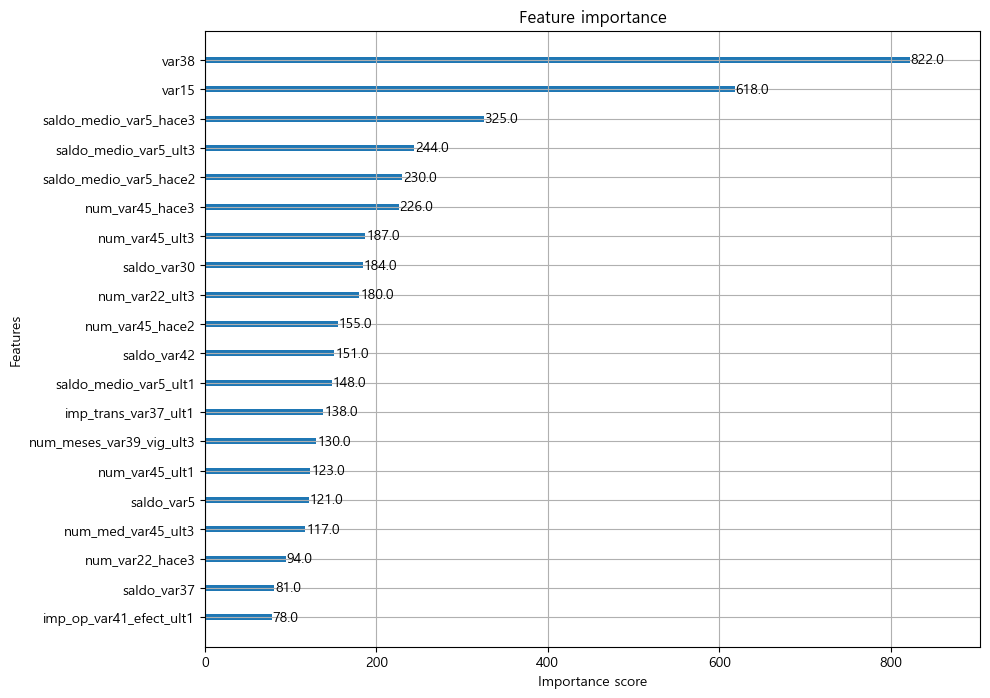

In [22]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1,figsize=(10,8))
plot_importance(xgb_clf, ax=ax , max_num_features=20)
plt.show()

#### 수업시간에 나온 값
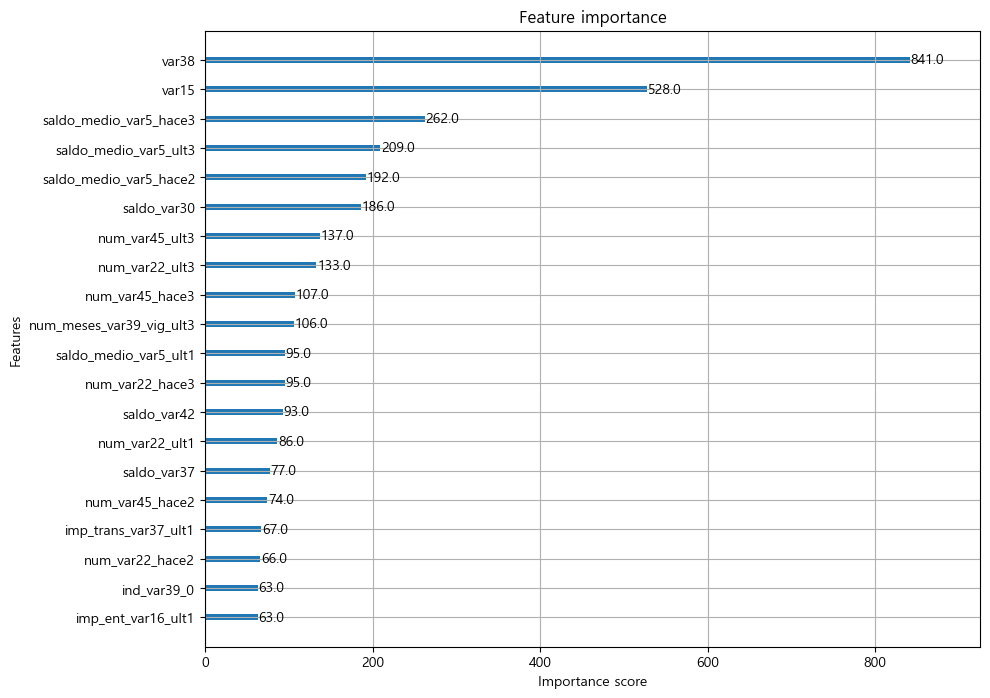

In [23]:
# var38 : 주거래 상품의 잔액, var15 : age, num_ : 거래횟수, saldo_ : 잔액, imp_ : 거래금액(상품별) => 다른 모델에서 sado_, num_, imp_ 는 정규화 좀 해야 할 끄다
cust_df['imp_trans_var37_ult1'].describe()

# BASE MODEL에서 HyperOpt Tuning 해서 ROC AUC값을 좀 향상시킨거다~ 
# 하지만 BASE model이 좋은 이유는 default값이 나쁜 값이 아니당 

count    7.602000e+04
mean     1.932954e+03
std      2.535572e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.310003e+06
Name: imp_trans_var37_ult1, dtype: float64

In [ ]:
# --------------------------------------------------------------- #
# LightGBM 으로 다시 해 보자 
from lightgbm import LGBMClassifier
import lightgbm as lgbm

lgbm_clf = LGBMClassifier(n_estimators=1000)

eval_set = [(X_val, y_val)]
lgbm_clf.fit(X_tr, y_tr, callbacks=[lgbm.early_stopping(100)], eval_metric='auc', eval_set=eval_set)
lgbm_score = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:,-1])
print(f'LGBM Base ROC AUC Score : {lgbm_score:.4f}') 
# LGBM Base ROC AUC Score : 0.8384 vs                  | LGBM Base ROC AUC Score : 0.8186
# XGBoost Base Model 0.8385 vs 
# XGBoost ROC AUC score : 0.8444 (Tuning)

[LightGBM] [Info] Number of positive: 1716, number of negative: 40855
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016970 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13332
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 248
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.040309 -> initscore=-3.170033
[LightGBM] [Info] Start training from score -3.170033
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[46]	valid_0's auc: 0.829614	valid_0's binary_logloss: 0.132247
LGBM Base ROC AUC Score : 0.8186


In [25]:
# LGBM Tuning
from hyperopt import hp

lgbm_search_space = {
    'num_leaves'        : hp.quniform('num_leaves', 32, 64, 1), # Lgbm은 leaf-wise
    'max_depth'         : hp.quniform('max_depth', 100, 160, 1), # Lgbm은 좀 깊게 줘야 한다, XGBoost는 5,15,1 로 줬었다
    'min_child_samples' : hp.quniform('min_child_samples',  60, 199, 1),
    'subsample'         : hp.uniform('subsample', 0.7, 1) , # 데이터 갯수 비율
    'learning_rate'     : hp.uniform('learning_rate', 0.01, 0.2), # DL에서는 겁나 중요혀!!!!      
}

def objective_func(search_space):
    lgbm_clf = LGBMClassifier(
      n_estimators      = 100, 
      max_depth         = int(search_space['max_depth']),
      num_leaves        =  int(search_space['num_leaves']),
      min_child_samples = int(search_space['min_child_samples']),
      subsample         = search_space['subsample'],
      learning_rate     = search_space['learning_rate']
    )
    
    roc_auc_list = []
    
    kf = KFold(n_splits=3)
    
    for tr_idx, val_idx in kf.split(X_train):
        X_tr,  y_tr  = X_train.iloc[tr_idx], y_train.iloc[tr_idx],
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        lgbm_clf.fit(
          X_tr, y_tr, 
          callbacks   = [lgbm.early_stopping(30)], 
          eval_metric = 'auc', 
          eval_set    = [(X_val, y_val)]
        )
        score = roc_auc_score(y_val, lgbm_clf.predict_proba(X_val)[:,1])
        roc_auc_list.append(score)
        
    return -1 * np.mean(roc_auc_list)
  

In [26]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

best = fmin( 
      fn        = objective_func,
      space     = lgbm_search_space,
      trials    = trials,
      algo      = tpe.suggest,
      max_evals = 50,
      rstate    = np.random.default_rng(seed=30)
)

print(f'Tuning LGBM Best Parameter : {best}')

[LightGBM] [Info] Number of positive: 1628, number of negative: 38916
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015632 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12630                    
[LightGBM] [Info] Number of data points in the train set: 40544, number of used features: 184
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.040154 -> initscore=-3.174053
[LightGBM] [Info] Start training from score -3.174053 
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:       
[100]	valid_0's auc: 0.841696	valid_0's binary_logloss: 0.131736
[LightGBM] [Info] Number of positive: 1591, number of negative: 38953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012697 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightG

In [ ]:
lgbm_clf = LGBMClassifier(
  n_estimators      = 1000,
  num_leaves        = int(best['num_leaves']),
  max_depth         = int(best['max_depth']),
  min_child_samples = int(best['min_child_samples']),
  subsample         = round(best['subsample'], 5),
  learning_rate     = round(best['learning_rate'], 5)
)

lgbm_clf.fit(
  X_tr, y_tr, 
  callbacks   = [lgbm.early_stopping(100)],
  eval_metric = 'auc',
  eval_set    = [(X_val, y_val)]
)
score = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:,1])
print(f'LGBM Turning Roc Auc Score : {score:.4f}') # LGBM Turning Roc Auc Score : 0.8425

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[111]	valid_0's auc: 0.834983	valid_0's binary_logloss: 0.134586
LGBM Turning Roc Auc Score : 0.8425
